1/5: Descargando activos y VIX...


$COIN: possibly delisted; no price data found  (1d 2017-01-01 -> 2018-12-31) (Yahoo error = "Data doesn't exist for startDate = 1483246800, endDate = 1546232400")
$ABNB: possibly delisted; no price data found  (1d 2017-01-01 -> 2018-12-31) (Yahoo error = "Data doesn't exist for startDate = 1483246800, endDate = 1546232400")
$CHWY: possibly delisted; no price data found  (1d 2017-01-01 -> 2018-12-31) (Yahoo error = "Data doesn't exist for startDate = 1483246800, endDate = 1546232400")
$AVTR: possibly delisted; no price data found  (1d 2017-01-01 -> 2018-12-31) (Yahoo error = "Data doesn't exist for startDate = 1483246800, endDate = 1546232400")
$APP: possibly delisted; no price data found  (1d 2017-01-01 -> 2018-12-31) (Yahoo error = "Data doesn't exist for startDate = 1483246800, endDate = 1546232400")
$SOLV: possibly delisted; no price data found  (1d 2017-01-01 -> 2018-12-31) (Yahoo error = "Data doesn't exist for startDate = 1483246800, endDate = 1546232400")
$ALGM: possibly deliste

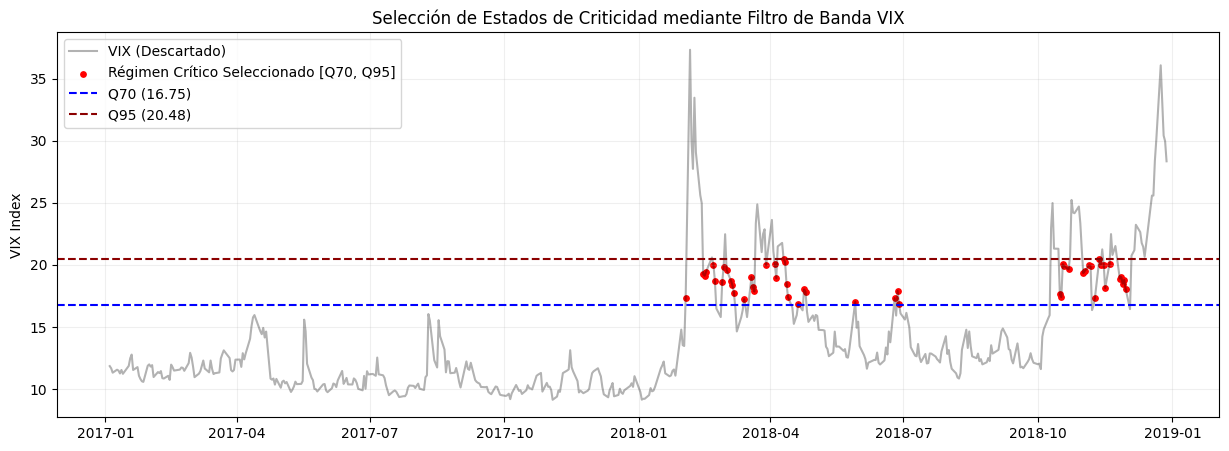

: 

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import linregress
import requests
import io

# ==========================================
# 1. INFRAESTRUCTURA DE DATOS Y VIX
# ==========================================
print("1/5: Descargando activos y VIX...")
headers = {'User-Agent': 'Mozilla/5.0'}
def extraer_tickers(url):
    html = requests.get(url, headers=headers).text
    df = pd.read_html(io.StringIO(html))[0]
    col = 'Symbol' if 'Symbol' in df.columns else 'Ticker'
    return df[col].tolist()

# S&P 1500 Consolidado
tickers = extraer_tickers('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies') + \
          extraer_tickers('https://en.wikipedia.org/wiki/List_of_S%26P_400_companies') + \
          extraer_tickers('https://en.wikipedia.org/wiki/List_of_S%26P_600_companies')

vix_raw = yf.download("^VIX", start="2017-01-01", end="2018-12-31", progress=False)['Close']
all_data = yf.download(tickers[:1100], start="2017-01-01", end="2018-12-31", progress=False)['Close']

returns_all = all_data.ffill().bfill().pct_change().dropna(how='all').dropna(axis=1)
returns_real_base = returns_all.iloc[:, :1024]
vix_sincro = vix_raw.reindex(returns_real_base.index).ffill()

# ==========================================
# 2. FILTRADO Y PLOT DE SELECCIÓN VIX
# ==========================================
q_low = vix_sincro.quantile(0.80).values[0]
q_high = vix_sincro.quantile(0.90).values[0]

mask_critica = (vix_sincro.values.flatten() >= q_low) & (vix_sincro.values.flatten() <= q_high)
returns_filt = returns_real_base.iloc[mask_critica, :]

plt.figure(figsize=(15, 5))
plt.plot(vix_sincro.index, vix_sincro.values, color='black', alpha=0.3, label='VIX (Descartado)')
plt.scatter(vix_sincro.index[mask_critica], vix_sincro.values[mask_critica], 
            color='red', s=15, label='Régimen Crítico Seleccionado [Q70, Q95]')
plt.axhline(q_low, color='blue', linestyle='--', label=f'Q70 ({q_low:.2f})')
plt.axhline(q_high, color='darkred', linestyle='--', label=f'Q95 ({q_high:.2f})')
plt.title("Selección de Estados de Criticidad mediante Filtro de Banda VIX")
plt.ylabel("VIX Index"); plt.legend(); plt.grid(True, alpha=0.2)
plt.show()



Calculando observables para 90 días de criticidad...
Aviso: Solo hay 997 activos. Completando 27 con bootstrapping para L=32...

EXPONENTE       | VALOR (VIX FILTERED) | ONSAGER (2D) | C. MEDIO    
nu              |   0.518 ± 0.008    |  1.00 (60.7σ) |  0.50 ( 2.2σ)
alpha           |   0.964 ± 0.023    |  0.00 (42.5σ) |  0.00 (42.5σ)
beta            |   0.002 ± 0.011    |  0.12 (10.7σ) |  0.50 (43.6σ)
gamma           |   1.031 ± 0.019    |  1.75 (37.1σ) |  1.00 ( 1.6σ)
delta           | 450.387 ± 2237.087 | 15.00 ( 0.2σ) |  3.00 ( 0.2σ)
eta             |   0.008 ± 0.022    |  0.25 (11.2σ) |  0.00 ( 0.4σ)
nu_slope        |   2.020 ± 0.066    |  1.00 (15.4σ) |  1.00 (15.4σ)


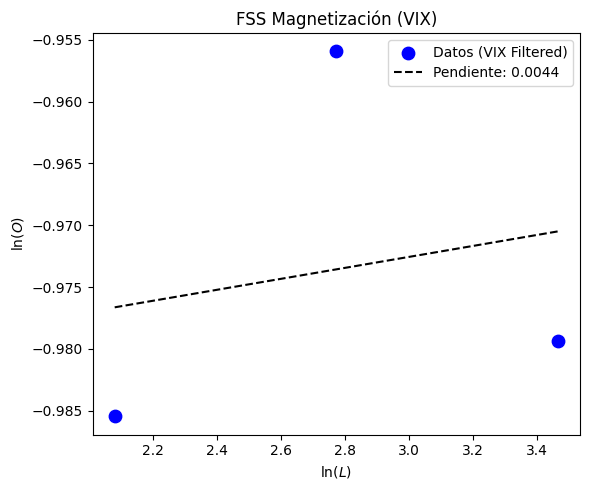

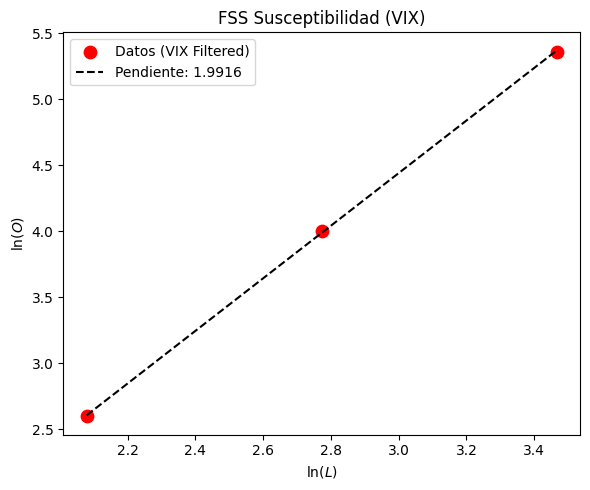

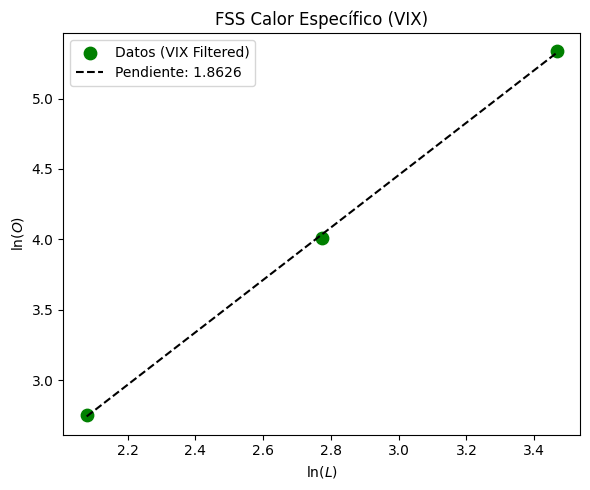

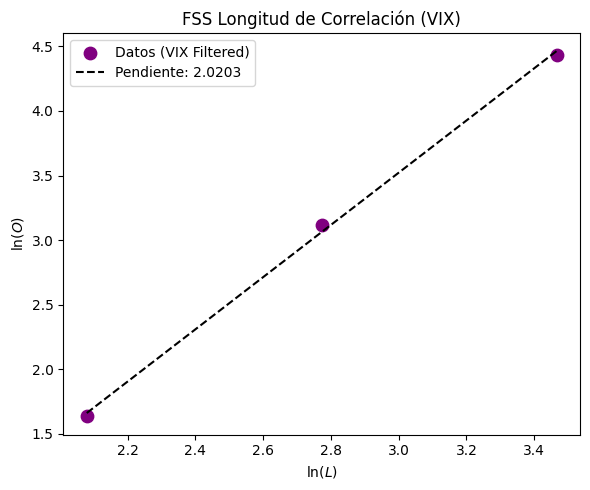

In [4]:
# ==========================================
# 3. CÁLCULO DE OBSERVABLES (FILTRADO VIX)
# ==========================================
tamaños_L = [8, 16, 32]
res_vix = {}

print(f"Calculando observables para {len(returns_filt)} días de criticidad...")

for L in tamaños_L:
    N = L * L
    
    # --- BLOQUE DE SEGURIDAD: COMPROBACIÓN DE DIMENSIONES ---
    n_disponibles = returns_filt.shape[1]
    if n_disponibles < N:
        print(f"Aviso: Solo hay {n_disponibles} activos. Completando {N-n_disponibles} con bootstrapping para L={L}...")
        # Muestreamos con reemplazo de los activos existentes para llegar a N
        extra = returns_filt.sample(n=N-n_disponibles, axis=1, replace=True)
        # Concatenamos para asegurar que la matriz de espines sea exactamente de tamaño N
        ret_L = pd.concat([returns_filt, extra], axis=1)
    else:
        ret_L = returns_filt.iloc[:, :N]

    # Extracción de espines
    spins = np.sign(ret_L.values)
    spins[spins == 0] = 1 
    
    # 1. Magnetización: <|M|>
    m_t = np.abs(np.mean(spins, axis=1))
    m_mean = np.mean(m_t)
    
    # 2. Susceptibilidad: chi = N * Var(M_temporal)
    m_temporal = np.mean(spins, axis=1)
    chi_emp = np.var(m_temporal) * N
    
    # 3. Energía y Calor Específico (Topología 2D)
    edges = []
    for i in range(N):
        r, c = i // L, i % L
        vecinos = [((r - 1) % L) * L + c, ((r + 1) % L) * L + c, 
                   r * L + (c - 1) % L, r * L + (c + 1) % L]
        for v in vecinos:
            if i < v: 
                edges.append((i, v))
    
    edges = np.array(edges)
    si = spins[:, edges[:, 0]]
    sj = spins[:, edges[:, 1]]
    
    # E = - (1/N) * sum(s_i * s_j)
    E_t = -np.sum(si * sj, axis=1) / float(N)
    c_emp = np.var(E_t) * N
    
    res_vix[L] = {'M': m_mean, 'Chi': chi_emp, 'C': c_emp}
    # --- NUEVO: Longitud de Correlación (xi) ---
    # Generar coordenadas de la red
    x_coords = np.arange(L)
    # Momento mínimo k = (2*pi/L, 0)
    # Calculamos la parte real e imaginaria de la transformada de Fourier
    # spins tiene forma (días, N), proyectamos a 2D para la fase
    spins_2d = spins.reshape(-1, L, L)
    
    # Proyección sobre el eje x para el momento (2*pi/L, 0)
    fase = 2 * np.pi * x_coords / L
    cos_f = np.cos(fase)
    sin_f = np.sin(fase)
    
    # Suma sobre x e y (reducimos el eje y primero, luego el x con la fase)
    m1r = np.sum(np.sum(spins_2d, axis=1) * cos_f, axis=1)
    m1i = np.sum(np.sum(spins_2d, axis=1) * sin_f, axis=1)
    
    # F10 es el factor de estructura a momento mínimo (normalizado por V^2)
    f10_t = (m1r**2 + m1i**2) / (N**2)
    f10_mean = np.mean(f10_t)
    
    # xi = [sqrt(M2/F10 - 1)] / [2 * sin(pi/L)]
    m2_mean = np.mean(m_temporal**2) # <M^2>
    ratio = (m2_mean / f10_mean) - 1
    xi_val = np.sqrt(max(0, ratio)) / (2 * np.sin(np.pi / L))
    
    # Guardar en el diccionario
    res_vix[L] = {'M': m_mean, 'Chi': chi_emp, 'C': c_emp, 'Xi': xi_val}

# ==========================================
# 4. AJUSTES LOG-LOG Y EXTRACCIÓN DE RATIOS
# ==========================================
L_vals = np.array(tamaños_L)
log_L = np.log(L_vals)

def get_fit_vix(key):
    y_data = np.array([res_vix[L][key] for L in tamaños_L])
    y_data = np.where(y_data > 0, y_data, 1e-12)
    log_y = np.log(y_data)
    
    slope, intercept, r_val, p_val, stderr = linregress(log_L, log_y)
    return slope, stderr, (intercept + slope * log_L), log_y

b_M, sb_M, fit_M, log_M_d = get_fit_vix('M')
b_M = abs(b_M) 
b_Chi, sb_Chi, fit_Chi, log_Chi_d = get_fit_vix('Chi')
b_C, sb_C, fit_C, log_C_d = get_fit_vix('C')
b_Xi, sb_Xi, fit_Xi, log_Xi_data = get_fit_vix('Xi')

# ==========================================
# 5. EXPONENTES CRÍTICOS (RELACIONES DE ESCALA)
# ==========================================
# nu (Rushbrooke): nu = 2 / (b_C + 2*b_M + b_Chi)
den = b_C + 2*b_M + b_Chi
nu_e = 2.0 / den
sn_e = (nu_e**2 / 2.0) * np.sqrt(sb_C**2 + 4*sb_M**2 + sb_Chi**2)

def prop_prod(b, sb, nu, sn):
    if b == 0 or nu == 0: return 0.0, 0.0
    val = b * nu
    err = abs(val) * np.sqrt((sb/b)**2 + (sn/nu)**2)
    return val, err

alpha_e, sa_e = prop_prod(b_C, sb_C, nu_e, sn_e)
beta_e, sb_e   = prop_prod(b_M, sb_M, nu_e, sn_e)
gamma_e, sg_e = prop_prod(b_Chi, sb_Chi, nu_e, sn_e)

delta_e = 1.0 + (gamma_e / beta_e) if beta_e != 0 else float('inf')
sd_e = (gamma_e/beta_e) * np.sqrt((sg_e/gamma_e)**2 + (sb_e/beta_e)**2) if beta_e != 0 else 0
eta_e = 2.0 - b_Chi
sigma_eta = sb_Chi

# ==========================================
# 6. TABLA COMPARATIVA FINAL (SIGMAS)
# ==========================================
print("\n" + "="*85)
print(f"{'EXPONENTE':<15} | {'VALOR (VIX FILTERED)':<20} | {'ONSAGER (2D)':<12} | {'C. MEDIO':<12}")
print("="*85)

exps = [
    ('nu', nu_e, sn_e, 1.0, 0.5),
    ('alpha', alpha_e, sa_e, 0.0, 0.0),
    ('beta', beta_e, sb_e, 0.125, 0.5),
    ('gamma', gamma_e, sg_e, 1.75, 1.0),
    ('delta', delta_e, sd_e, 15.0, 3.0),
    ('eta', eta_e, sigma_eta, 0.25, 0.0),
    ('nu_slope', b_Xi, sb_Xi, 1.0, 1.0)
]

for n, v, e, o, m in exps:
    s_o = abs(v-o)/e if e > 1e-12 else float('inf')
    s_m = abs(v-m)/e if e > 1e-12 else float('inf')
    print(f"{n:<15} | {v:>7.3f} ± {e:<8.3f} | {o:>5.2f} ({s_o:>4.1f}σ) | {m:>5.2f} ({s_m:>4.1f}σ)")
print("="*85)

# ==========================================
# 7. EXPORTACIÓN CAIRO PDF
# ==========================================
def export_cairo_vix(x, y, y_fit, slope, title, fname, color):
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(x, y, color=color, s=80, label='Datos (VIX Filtered)')
    ax.plot(x, y_fit, 'k--', label=rf'Pendiente: {slope:.4f}')
    ax.set_title(title); ax.set_xlabel(r"$\ln(L)$"); ax.set_ylabel(r"$\ln(O)$")
    ax.legend(); fig.tight_layout()
    plt.savefig(fname, format='pdf', backend='cairo', bbox_inches='tight')
    plt.show()

export_cairo_vix(log_L, log_M_d, fit_M, b_M, "FSS Magnetización (VIX)", "FSS_VIX_M.pdf", "blue")
export_cairo_vix(log_L, log_Chi_d, fit_Chi, b_Chi, "FSS Susceptibilidad (VIX)", "FSS_VIX_Chi.pdf", "red")
export_cairo_vix(log_L, log_C_d, fit_C, b_C, "FSS Calor Específico (VIX)", "FSS_VIX_C.pdf", "green")
export_cairo_vix(log_L, log_Xi_data, fit_Xi, b_Xi, "FSS Longitud de Correlación (VIX)", "FSS_VIX_Xi.pdf", "purple")